In [1]:
# ==========================================================
# MACHINE LEARNING
# Phase 7.3 : Model Evaluation
# ==========================================================

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# LOAD DATA
# ==========================================================

project_root = r"D:\AI-Powered-Customer-Retention-Intelligence-Platform"

os.chdir(project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

model_path = "data/processed/customer_retention_model_data.csv"

model_data = pd.read_csv(model_path)

print("Dataset loaded successfully.")
print("Shape:", model_data.shape)

Dataset loaded successfully.
Shape: (96096, 10)


In [3]:
# ==========================================================
# FEATURES AND TARGET
# ==========================================================

feature_columns = [
    "Frequency",
    "Monetary",
    "average_review_score",
    "preferred_payment_method",
    "average_order_value"
]

target_column = "churn_label"

X = model_data[feature_columns].copy()
y = model_data[target_column].copy()

numeric_features = [
    "Frequency",
    "Monetary",
    "average_review_score",
    "average_order_value"
]

categorical_features = [
    "preferred_payment_method"
]

print("Features:", feature_columns)
print("Target:", target_column)

Features: ['Frequency', 'Monetary', 'average_review_score', 'preferred_payment_method', 'average_order_value']
Target: churn_label


In [4]:
# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (76876, 5)
Testing Shape : (19220, 5)


In [5]:
# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [6]:
# ==========================================================
# TRAIN MODELS
# ==========================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[model_name] = pipeline

print("All models trained successfully.")

All models trained successfully.


In [7]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

evaluation_results = []

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    y_probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    evaluation_results.append(
        {
            "Model": model_name,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1_Score": round(f1, 4),
            "ROC_AUC": round(roc_auc, 4)
        }
    )

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df = evaluation_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)

print(evaluation_df)

MODEL EVALUATION RESULTS
                 Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
0    Gradient Boosting    0.7139     0.7149  0.9941    0.8317   0.6001
1        Random Forest    0.7127     0.7143  0.9935    0.8311   0.5905
2  Logistic Regression    0.7114     0.7142  0.9909    0.8301   0.5559
3        Decision Tree    0.7113     0.7137  0.9923    0.8302   0.5547


In [8]:
# ==========================================================
# CLASSIFICATION REPORTS
# ==========================================================

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Active / Retained",
                "Churn-Risk"
            ],
            zero_division=0
        )
    )


Logistic Regression
                   precision    recall  f1-score   support

Active / Retained       0.51      0.02      0.04      5549
       Churn-Risk       0.71      0.99      0.83     13671

         accuracy                           0.71     19220
        macro avg       0.61      0.51      0.44     19220
     weighted avg       0.65      0.71      0.60     19220


Decision Tree
                   precision    recall  f1-score   support

Active / Retained       0.50      0.02      0.04      5549
       Churn-Risk       0.71      0.99      0.83     13671

         accuracy                           0.71     19220
        macro avg       0.61      0.51      0.43     19220
     weighted avg       0.65      0.71      0.60     19220


Random Forest
                   precision    recall  f1-score   support

Active / Retained       0.57      0.02      0.04      5549
       Churn-Risk       0.71      0.99      0.83     13671

         accuracy                           0.71     192

In [9]:
# ==========================================================
# CONFUSION MATRICES
# ==========================================================

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(cm)


Logistic Regression
[[  128  5421]
 [  125 13546]]

Decision Tree
[[  106  5443]
 [  105 13566]]

Random Forest
[[  116  5433]
 [   89 13582]]

Gradient Boosting
[[  130  5419]
 [   80 13591]]


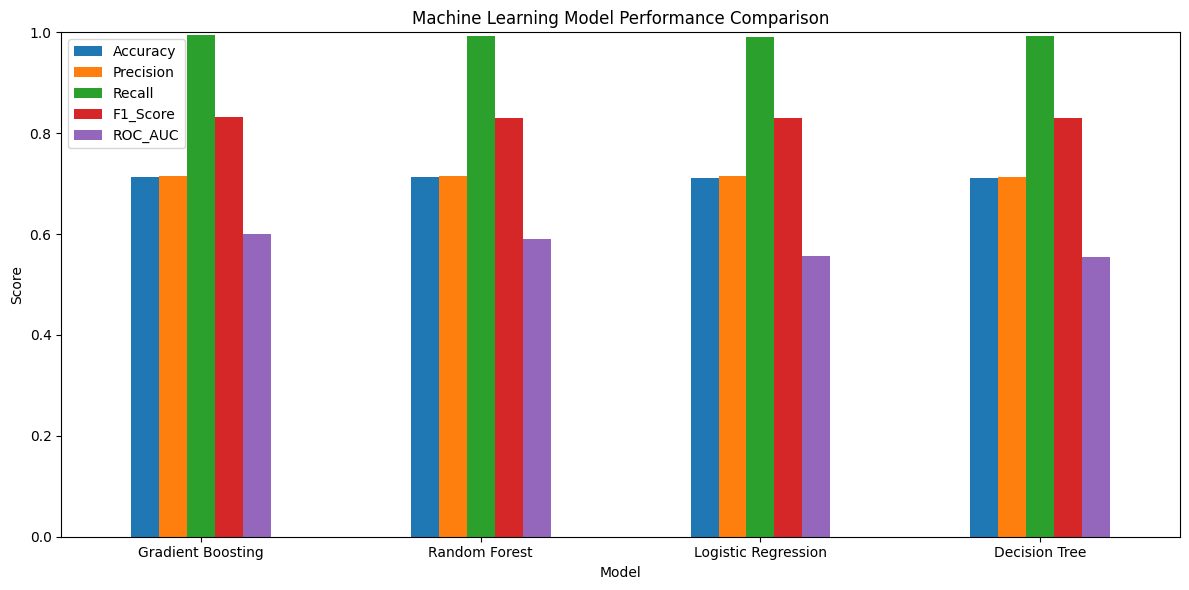

In [10]:
# ==========================================================
# MODEL PERFORMANCE COMPARISON
# ==========================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

evaluation_plot = evaluation_df.set_index("Model")[
    metrics_to_plot
]

evaluation_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()